# Introduction
In this project, we use a public dataset, Catalogue of HI PArameters (CHIPA), curated by the Argentine Astronomy Association. The dataset combines photometric and spectrometric surveys of nearby galaxies (NOVA, 2015). Due to the varying fields between the surveys, we
focus on one of them, THINGS: The HI Nearby Galaxy Survey. The survey contains informa-
tion about 34 galaxies such as declination, right ascension, mass, magnitude, and distance. We focus on the magnitude, which is a measure of the galaxy’s luminosity, but in an opposite direction, a higher magnitude corresponds to a lower luminosity. There are two types
of magnitude, absolute magnitude and relative magnitude. The latter represents the brightness
of the galaxies, and it depends on the distance, but the former depends solely on the intrinsic lu-
minosity of the galaxy (Carroll & Ostlie, 2014). Since the magnitude in this dataset is absolute,
it should be independent of the distance.
Therefore, we model the relationship between the magnitude and the mass, since the
mass indicates the number of stars in the galaxy, and the more stars in the galaxy the more
luminous it is. The mass is in Solar Mass units and ranges from 1.2 × 107 to 1.4 × 1010.

In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sts
import matplotlib.pyplot as plt
from IPython.display import Image

sns.set_theme(style="darkgrid")
az.style.use("arviz-darkgrid")

# Data Loading and Pre-processing

In [ ]:
# loading the data
data = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTYPDAUf_tDaq_14Db_MqtXwjJUoeFB-RBgriPlM_1Yhi2S5r2v0WN1_uykLDYMA4_afW4Ya1ADDXP0/pub?output=csv')
data.describe()

,ra,dec,optical_diam,mag,dist,angular,spec_resolution,flux,hi_diam,mass,inclination,vsys
count,33.000000,33.000000,33.0,33.000000,33.000000,33.0,0.0,32.000000,33.0,3.300000e+01,33.000000,33.000000
mean,155.471465,42.298215,0.0,-18.843939,6.715152,6.0,NaN,306.415625,0.0,3.006788e+09,3.781818,355.551515
std,65.199520,28.452711,0.0,2.621593,3.800668,0.0,NaN,338.303675,0.0,3.659929e+09,1.430134,281.919257
min,18.954167,-54.349167,0.0,-21.670000,2.000000,6.0,NaN,3.800000,0.0,1.200000e+07,1.300000,-85.600000
25%,128.529167,29.865833,0.0,-20.750000,3.600000,6.0,NaN,81.100000,0.0,4.080000e+08,2.600000,112.000000
50%,154.570833,44.094444,0.0,-19.920000,5.300000,6.0,NaN,229.500000,0.0,1.190000e+09,2.600000,346.400000
75%,187.045833,67.916667,0.0,-17.750000,9.200000,6.0,NaN,316.750000,0.0,4.150000e+09,5.200000,593.300000
max,339.266667,71.182222,0.0,-11.490000,17.700000,6.0,NaN,1169.000000,0.0,1.417000e+10,5.200000,815.600000


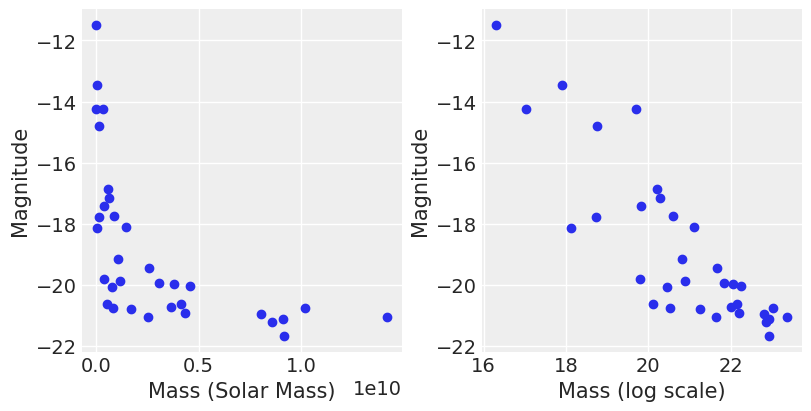

In [ ]:
# plotting the variables of interest
log_mass = np.log(data['mass'])
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(data['mass'], data['mag'])
ax[0].set_xlabel('Mass (Solar Mass)')
ax[0].set_ylabel('Magnitude')

ax[1].scatter(log_mass, data['mag'])
ax[1].set_xlabel('Mass (log scale)')
ax[1].set_ylabel('Magnitude')
plt.show()


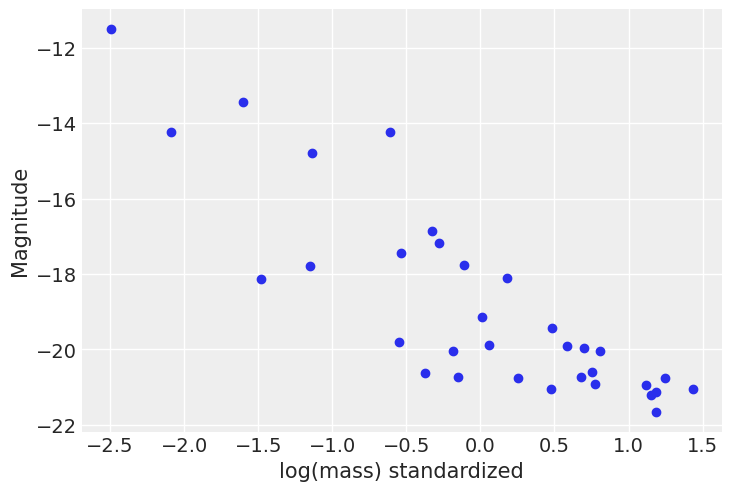

In [ ]:
# standardizing the predictor variable
mean_log_mass = log_mass.mean()
std_log_mass = log_mass.std()
log_mass_std = (log_mass - mean_log_mass) / std_log_mass

plt.scatter(log_mass_std, data['mag'])
plt.xlabel('log(mass) standardized')
plt.ylabel('Magnitude')
plt.show()

# Normal Likelihood

To apply linear regression, we use a Gaussian model, whose mean is a function of the predictor variable. Although we can use higher degrees of the predictor variable, it is still a linear regression since the function is linear in the coefficients. We mainly try the mean to be a first-order, second-order, and third-order polynomial function of the predictor and compare the three models. Yet, our first step is to decide the prior distribution and its parameters for the Gaussian sigma and the mean coefficients. 

## Prior Selection
While constructing the prior, we do not consider the observed data, but we try to make an informed decision based on prior knowledge of the variables. 
- **The prior for the intercept ($c_{0}$)**

     As mentioned earlier, the magnitude is a reversed scale for the luminosity. Although we, theoretically, cannot have a galaxy with 0 mass, we would expect the $y$-intercept to be at a high magnitude corresponding to a very low luminosity. The magnitude can take positive or negative values ranging from around -30 to 30. Therefore, we set the prior to be a \textbf{Normal} with a mean of 0 and a standard deviation of 10. In that case, it can have flexibility in exploring positive and negative values that are far from 0. 


- **The prior for the slope ($c_{1}$)**

    If we are only fitting a straight line, we would expect it to have a negative slope, reflecting the inverse relation between mass and magnitude. However, we are also fitting $2^{nd}$ and $3^{rd}$ degree polynomials whose coefficients share the same prior, and their coefficients can be positive or negative. Therefore, we use a \textbf{Normal} with a mean of 0 but with a relatively large standard deviation $(\sigma = 5)$ to allow for a wide range of values. Yet, the standard deviation is not too large, since we already standardized the predictor variable to avoid large coefficients. 
    

- **The prior for the Gaussian's standard deviation ($\sigma$)**

    Without considering the data, we do not have pre-assumptions for $\sigma$, except that it needs to be non-negative, so we set the prior to a **LogNormal** with a mean of 0 and a standard deviation of 1. 

Combining all the above, we can construct our model as follows
\begin{align*}
    mag &\sim \text{Normal}(\mu, \sigma) \quad (\text{likelihood})\\
    \sigma &\sim \text{LogNormal}(\mu=0, \sigma=1) \\
    \mu &= c_{0} + \sum_{i=1}^{n} c_{1i}x^{i}  \quad n \in (1, 3)\\
    c_{0} &\sim \text{Normal}(\mu=0, \sigma=10) \\
    c_{1} &\sim \text{Normal}(\mu=0, \sigma=5)
\end{align*}


In [ ]:
# constructing 3 polynomial fitting models
inferences_normal = []
predictive_normal = []
for degree in range(1, 4):
    with pm.Model() as model:
        mass = pm.Data('mass', log_mass_std)
        sigma = pm.LogNormal('sigma', mu=0, sigma=1)
        c0 = pm.Normal('c0', mu=0, sigma=10)
        c1 = pm.Normal('c1', mu=0, sigma=5, size=degree)
        mu = c0
        for i in range(1, degree + 1):
            mu = mu + c1[i-1] * mass ** i
        mu = pm.Deterministic('mu', mu)
        mag = pm.Normal('mag', mu=mu, sigma=sigma, observed=data['mag'])

        inference = pm.sample()
        pm.compute_log_likelihood(inference)
        predictive = pm.sample_posterior_predictive(inference)

    predictive_normal.append(predictive)
    inferences_normal.append(inference)

## Sampler Diagnostic

We define the models with different polynomial degrees in pymc, and we run a few diagnostics
that show that the sampler is, indeed, working well:
- arviz.summary():
    We find that ˆR for all parameters in the models is 1.0, which indicates the similarity
    between different parts of the chain. Moreover, ess_tail and ess_bulk are high for all
    parameters (> 700), indicating the prevalence of uncorrelated samples.

- arviz.plot_rank():
    All the rank plots across chains for all models and parameters are roughly uniformly
    distributed.


- arviz.plot_pair():
    We do not see any bi-modalities in the marginal distributions that could burden the sam-
    pler. The parameters are not correlated except for a slight correlation between c12 with
    both c10 and c11 . Yet, we see from the summary table that the contribution of c12 is
    minimal since it has a mean of -0.02.

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,-18.828,0.261,-19.302,-18.331,0.005,0.004,2411.0,1536.0,1.0
c1[0],-2.230,0.252,-2.683,-1.754,0.005,0.003,2583.0,1248.0,1.0
sigma,1.416,0.182,1.082,1.753,0.004,0.003,1998.0,1425.0,1.0


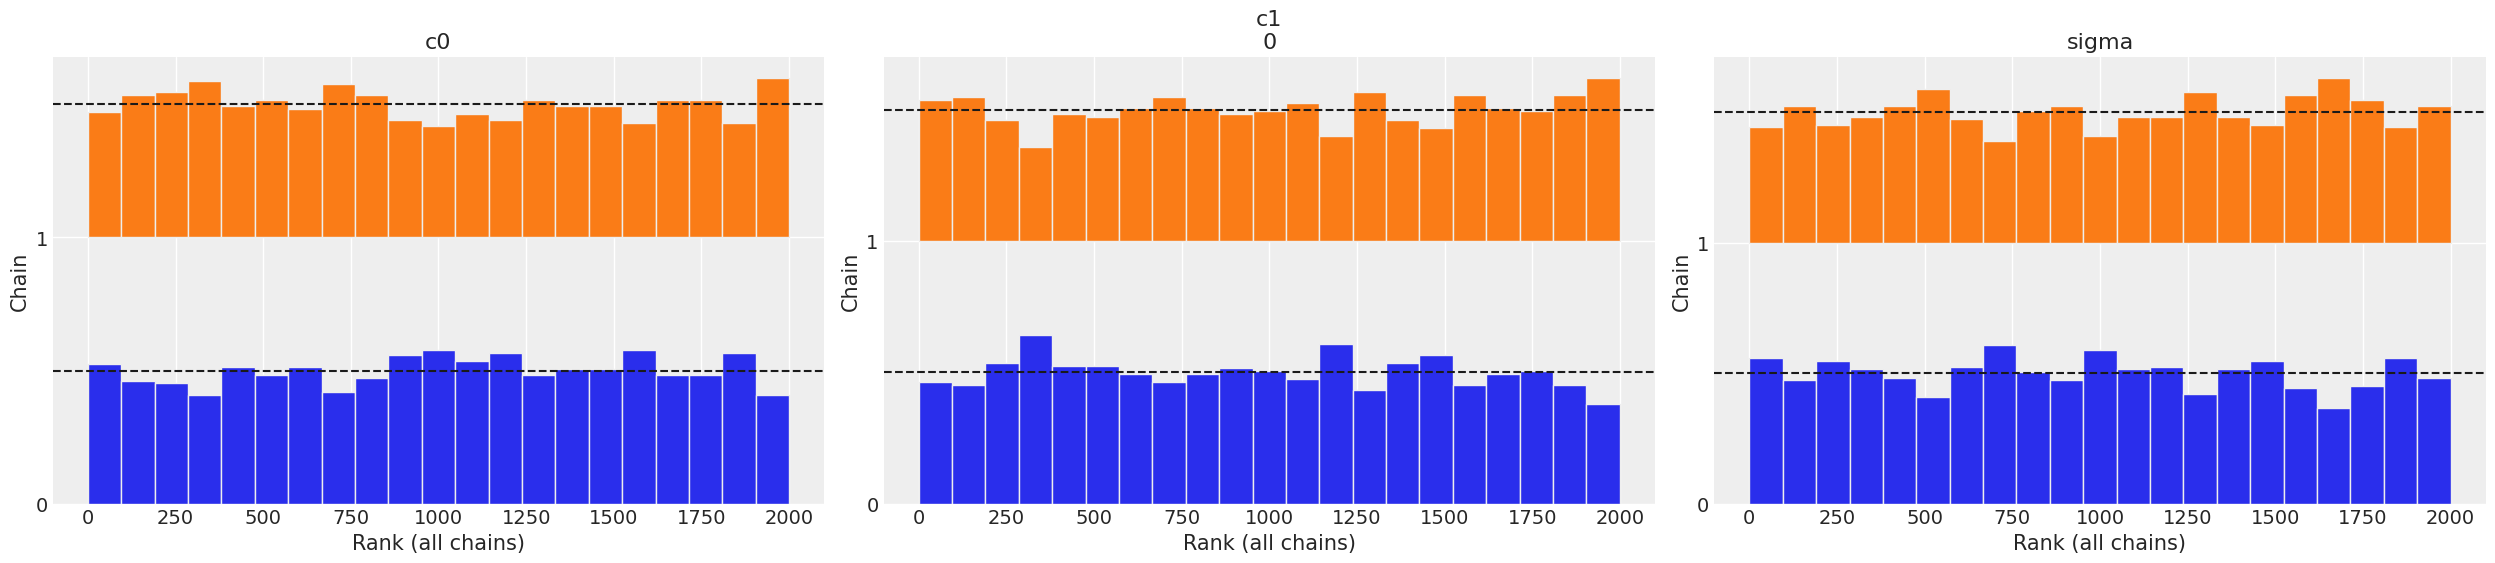

In [ ]:
# Diagnostic for 1st degree polynomial
az.plot_rank(inferences_normal[0], var_names=['c0', 'c1', 'sigma']);
az.summary(inferences_normal[0], var_names=['c0', 'c1', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,-19.161,0.317,-19.748,-18.575,0.009,0.006,1226.0,1131.0,1.00
c1[0],-2.009,0.280,-2.516,-1.498,0.008,0.005,1374.0,1247.0,1.01
c1[1],0.332,0.206,-0.075,0.706,0.006,0.004,1251.0,1499.0,1.00
sigma,1.372,0.175,1.056,1.692,0.005,0.004,1237.0,1173.0,1.00


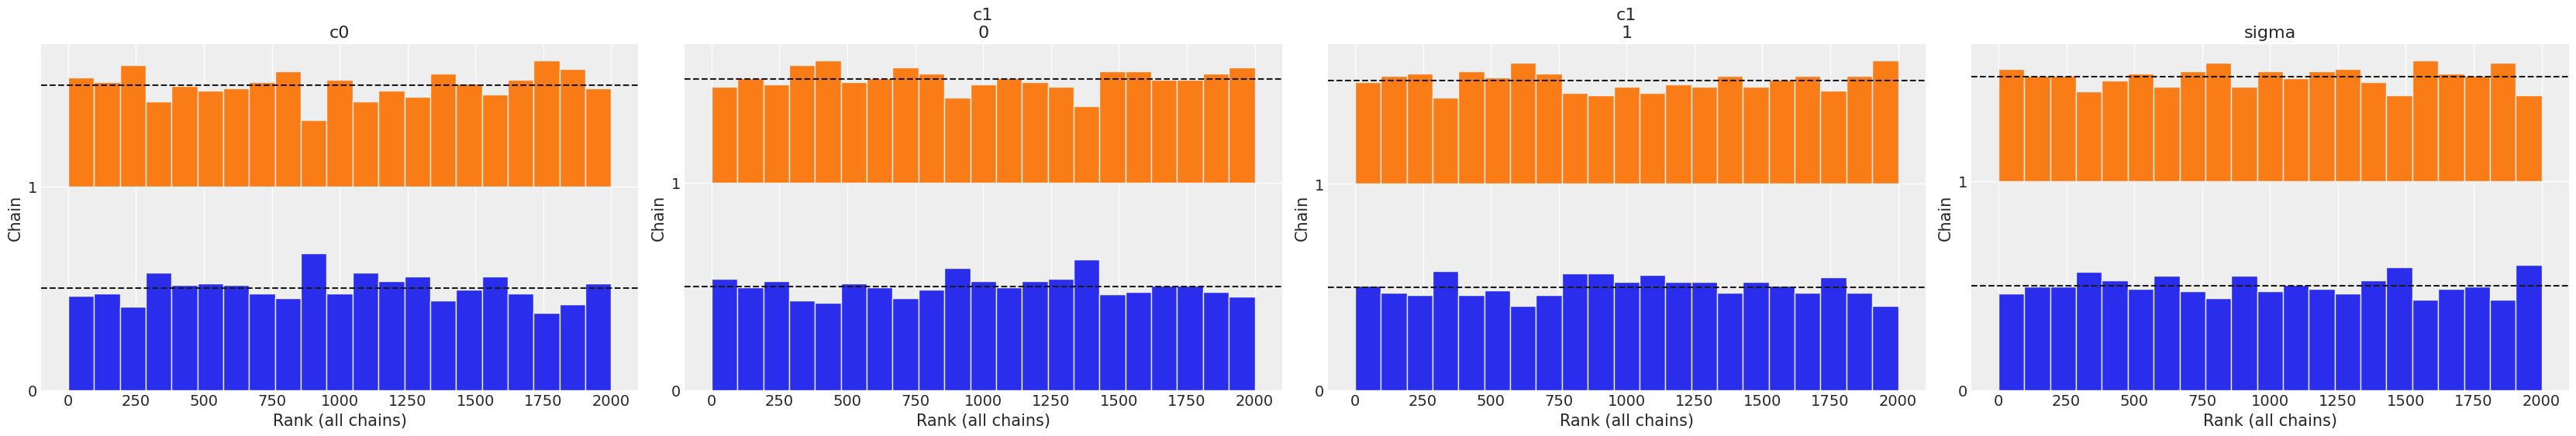

In [ ]:
# Diagnostic for 2nd degree polynomial
az.plot_rank(inferences_normal[1], var_names=['c0', 'c1', 'sigma']);
az.summary(inferences_normal[1], var_names=['c0', 'c1', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,-19.157,0.352,-19.833,-18.498,0.011,0.008,974.0,804.0,1.0
c1[0],-1.954,0.500,-2.864,-1.002,0.018,0.012,798.0,820.0,1.0
c1[1],0.312,0.370,-0.455,0.941,0.014,0.010,692.0,784.0,1.0
c1[2],-0.021,0.221,-0.437,0.387,0.009,0.006,612.0,785.0,1.0
sigma,1.398,0.194,1.085,1.770,0.006,0.004,1147.0,1236.0,1.0


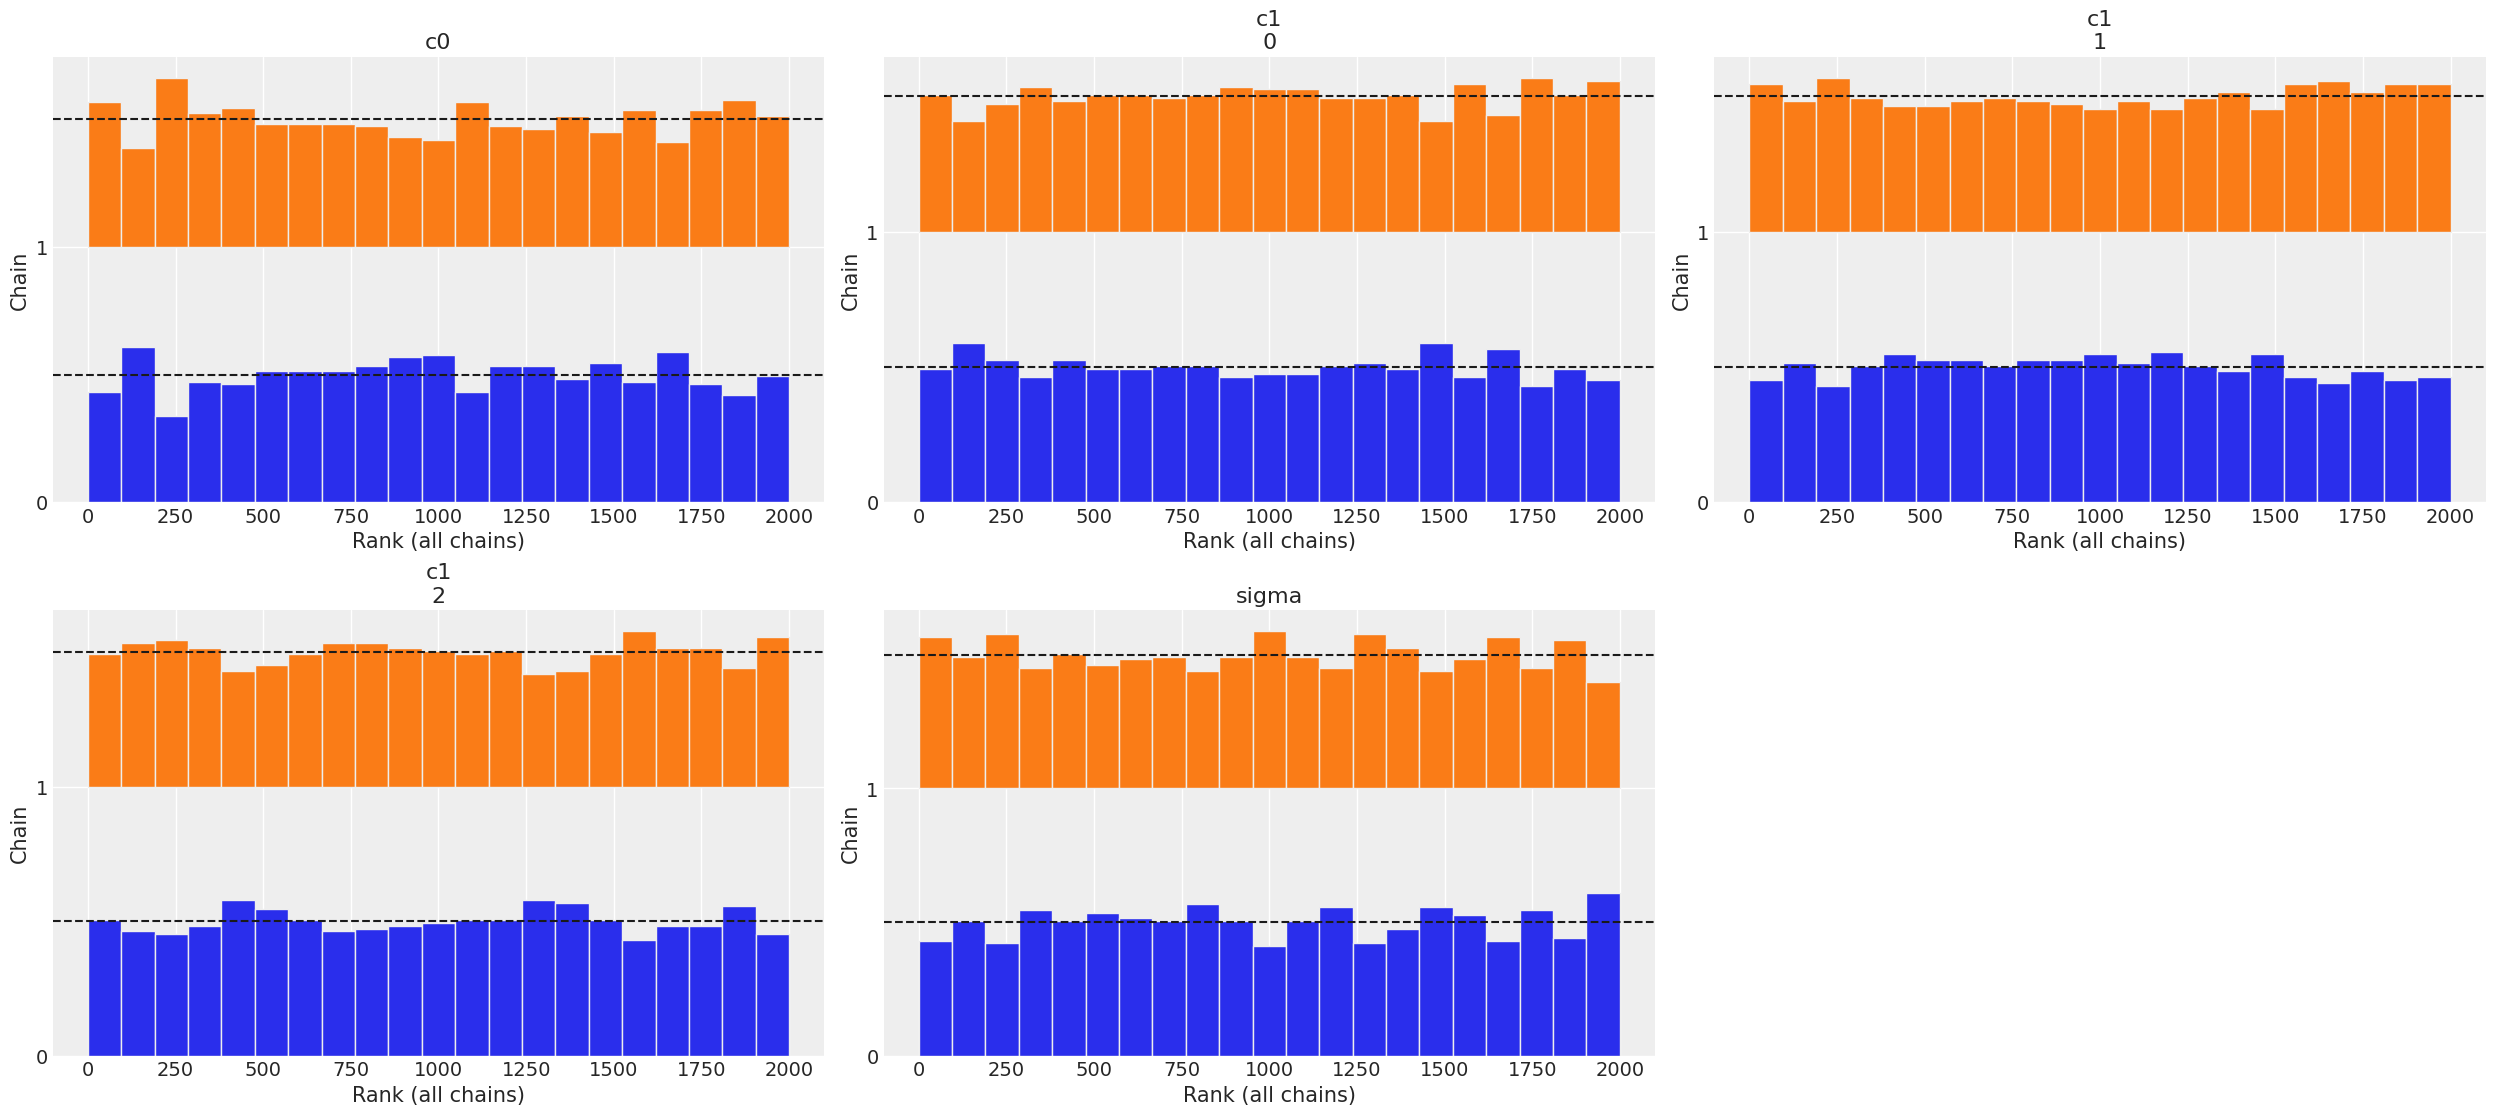

In [ ]:
# Diagnostic for 3rd degree polynomial
az.plot_rank(inferences_normal[2], var_names=['c0', 'c1', 'sigma']);
az.summary(inferences_normal[2], var_names=['c0', 'c1', 'sigma'])

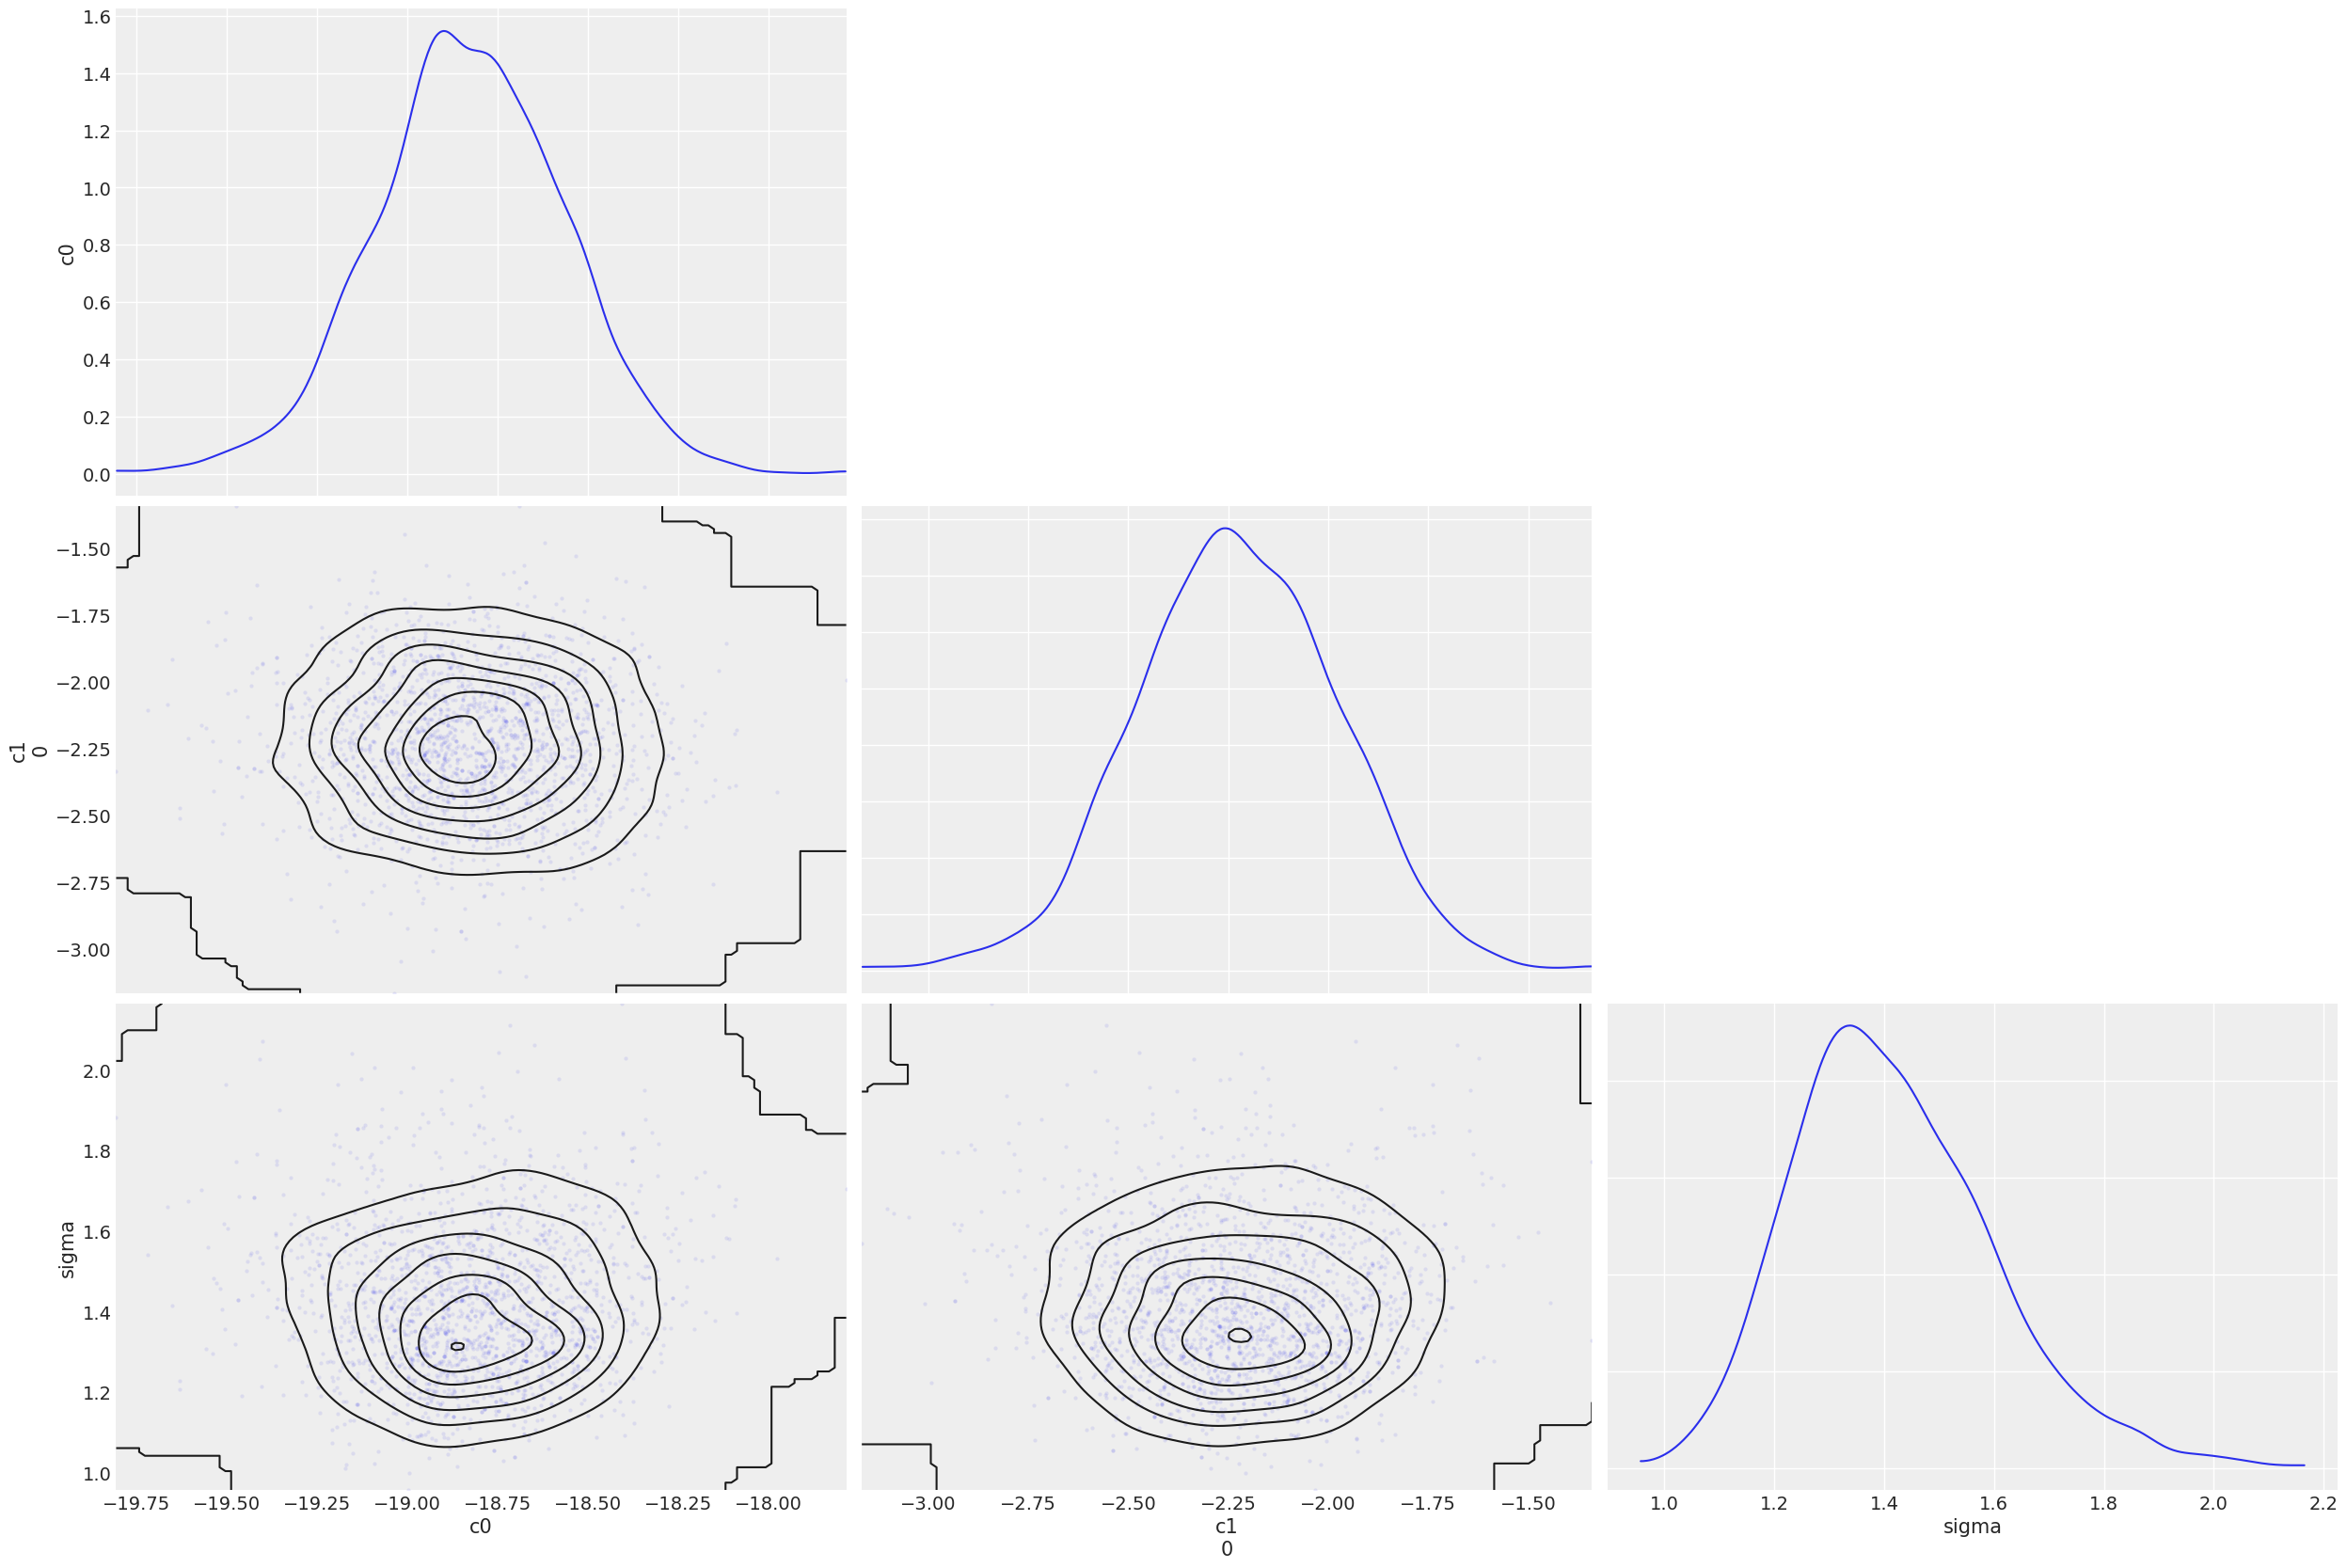

In [ ]:
az.plot_pair(inferences_normal[0],
             var_names=['c0', 'c1', 'sigma'],
             marginals=True,
             kind=["scatter", "kde"],
             scatter_kwargs={"color": "C0", "alpha": 0.1});

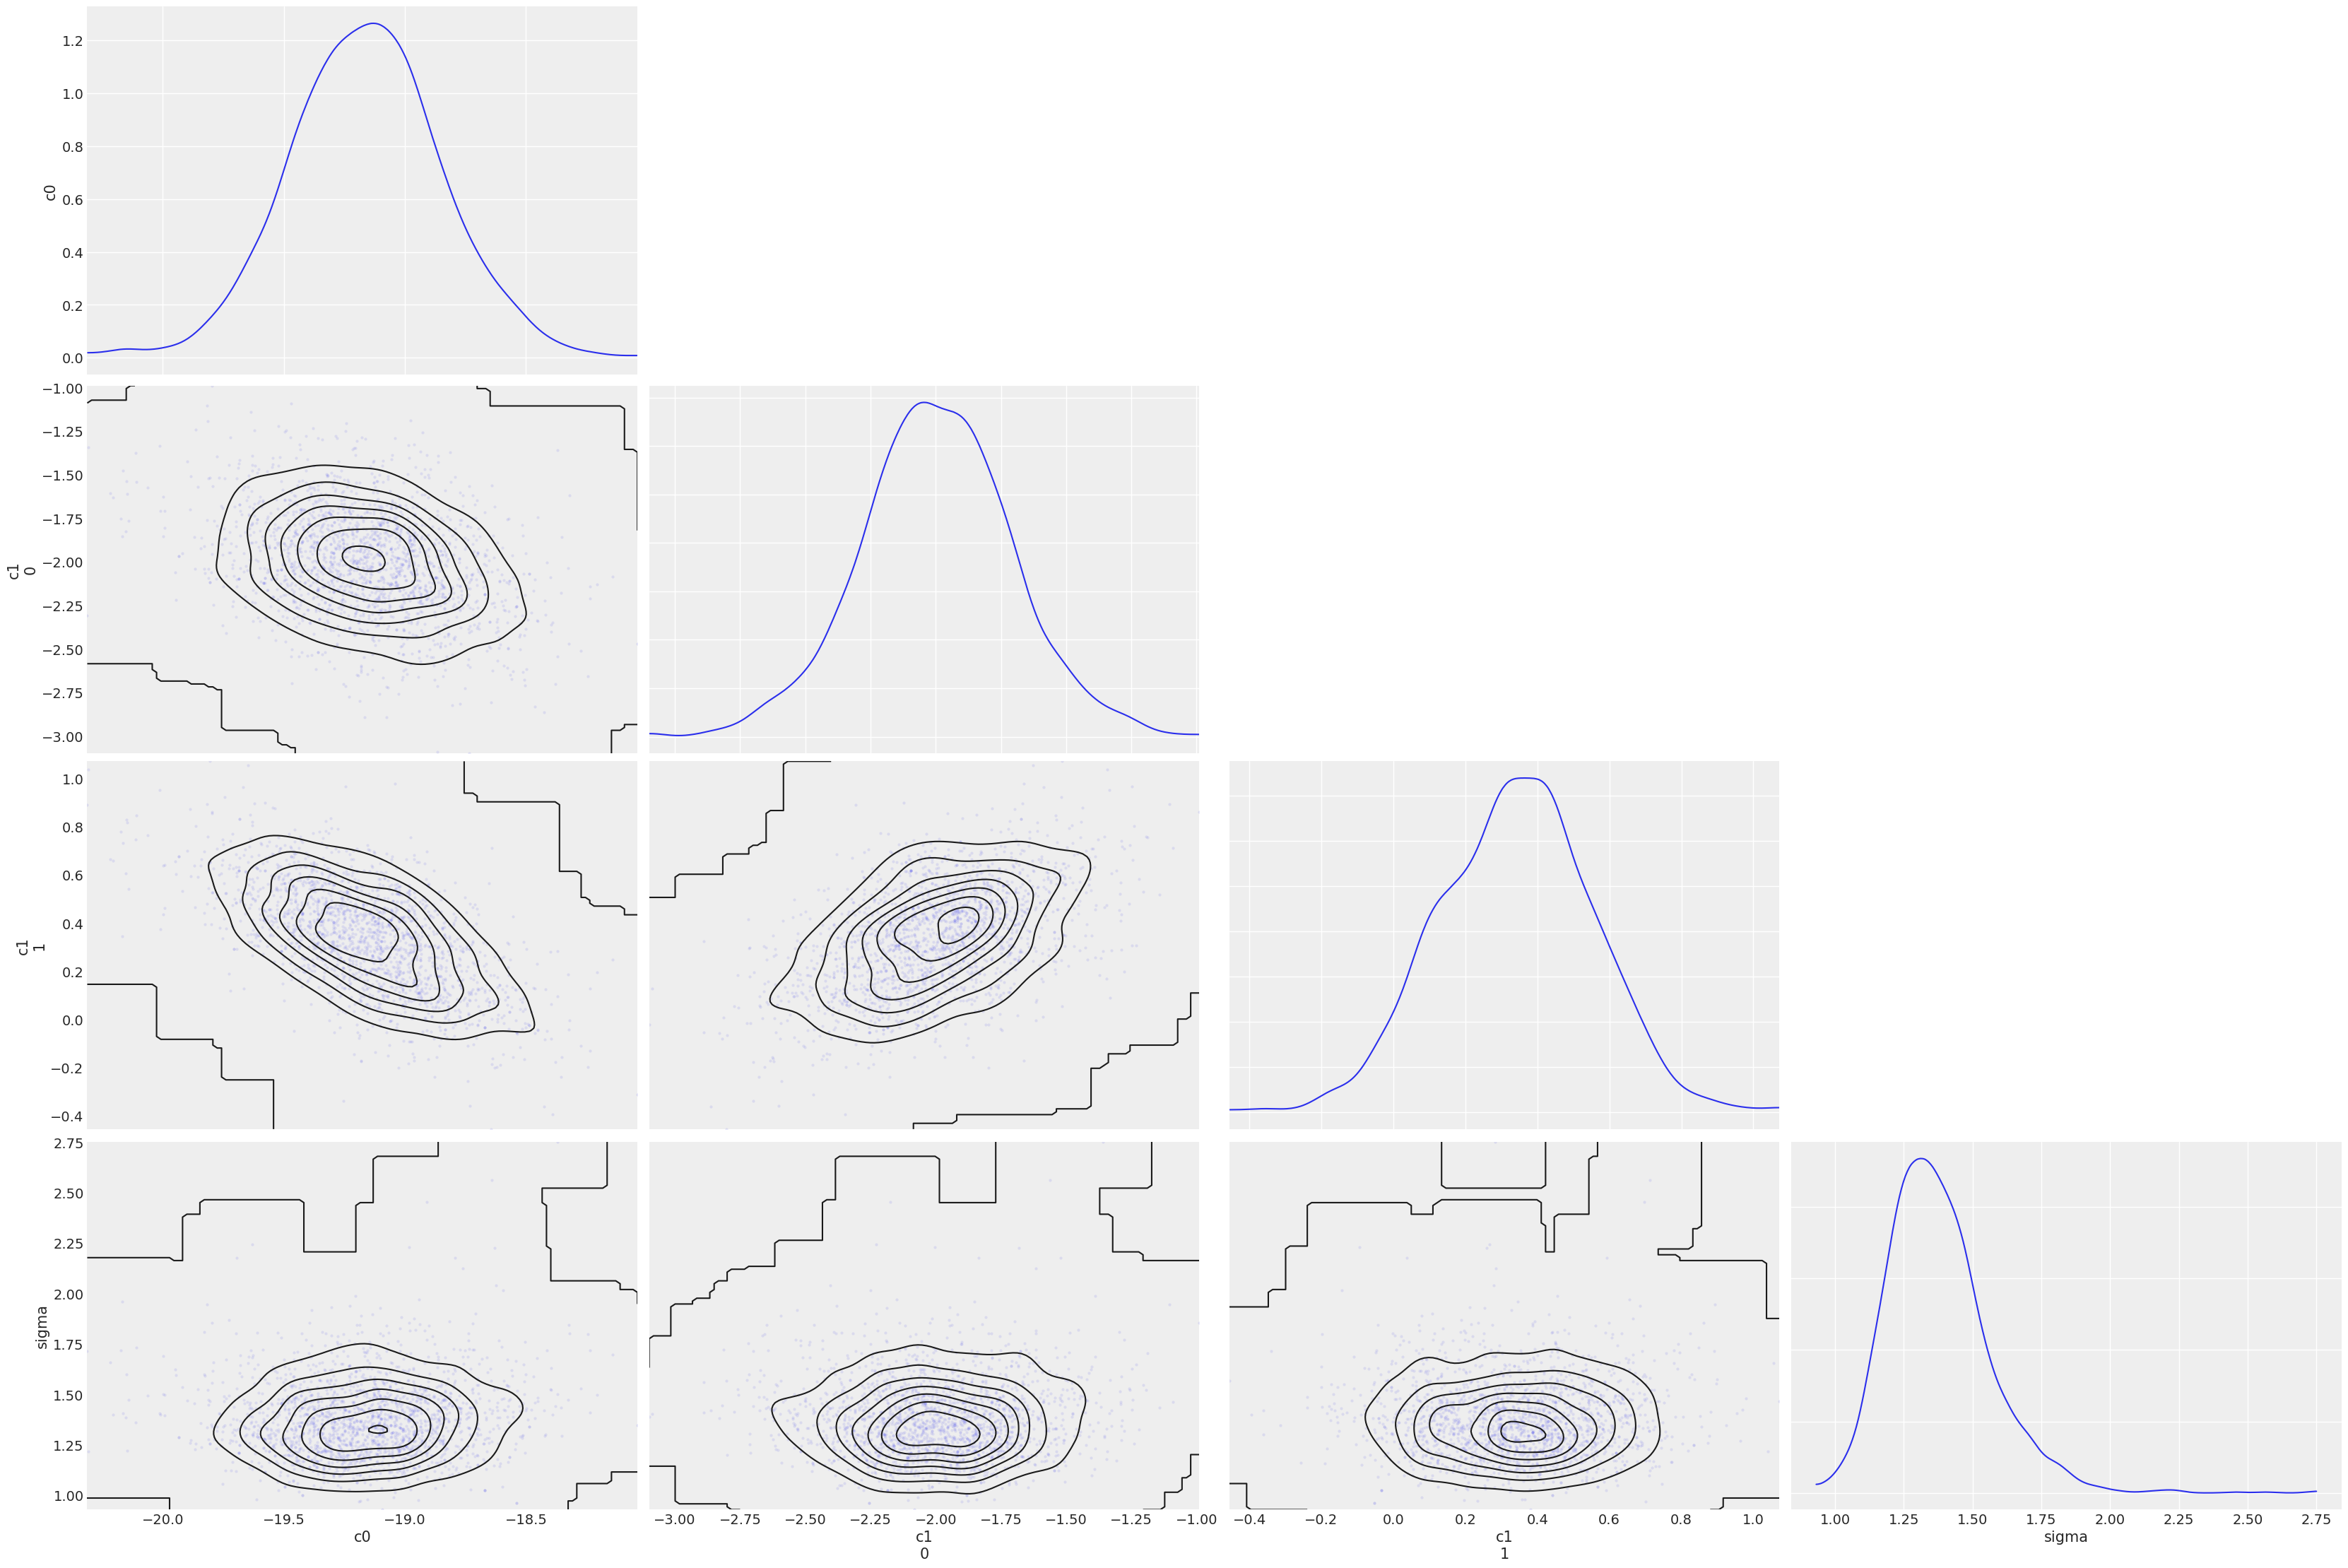

In [ ]:
az.plot_pair(inferences_normal[1],
             var_names=['c0', 'c1', 'sigma'],
             marginals=True,
             kind=["scatter", "kde"],
             scatter_kwargs={"color": "C0", "alpha": 0.1});

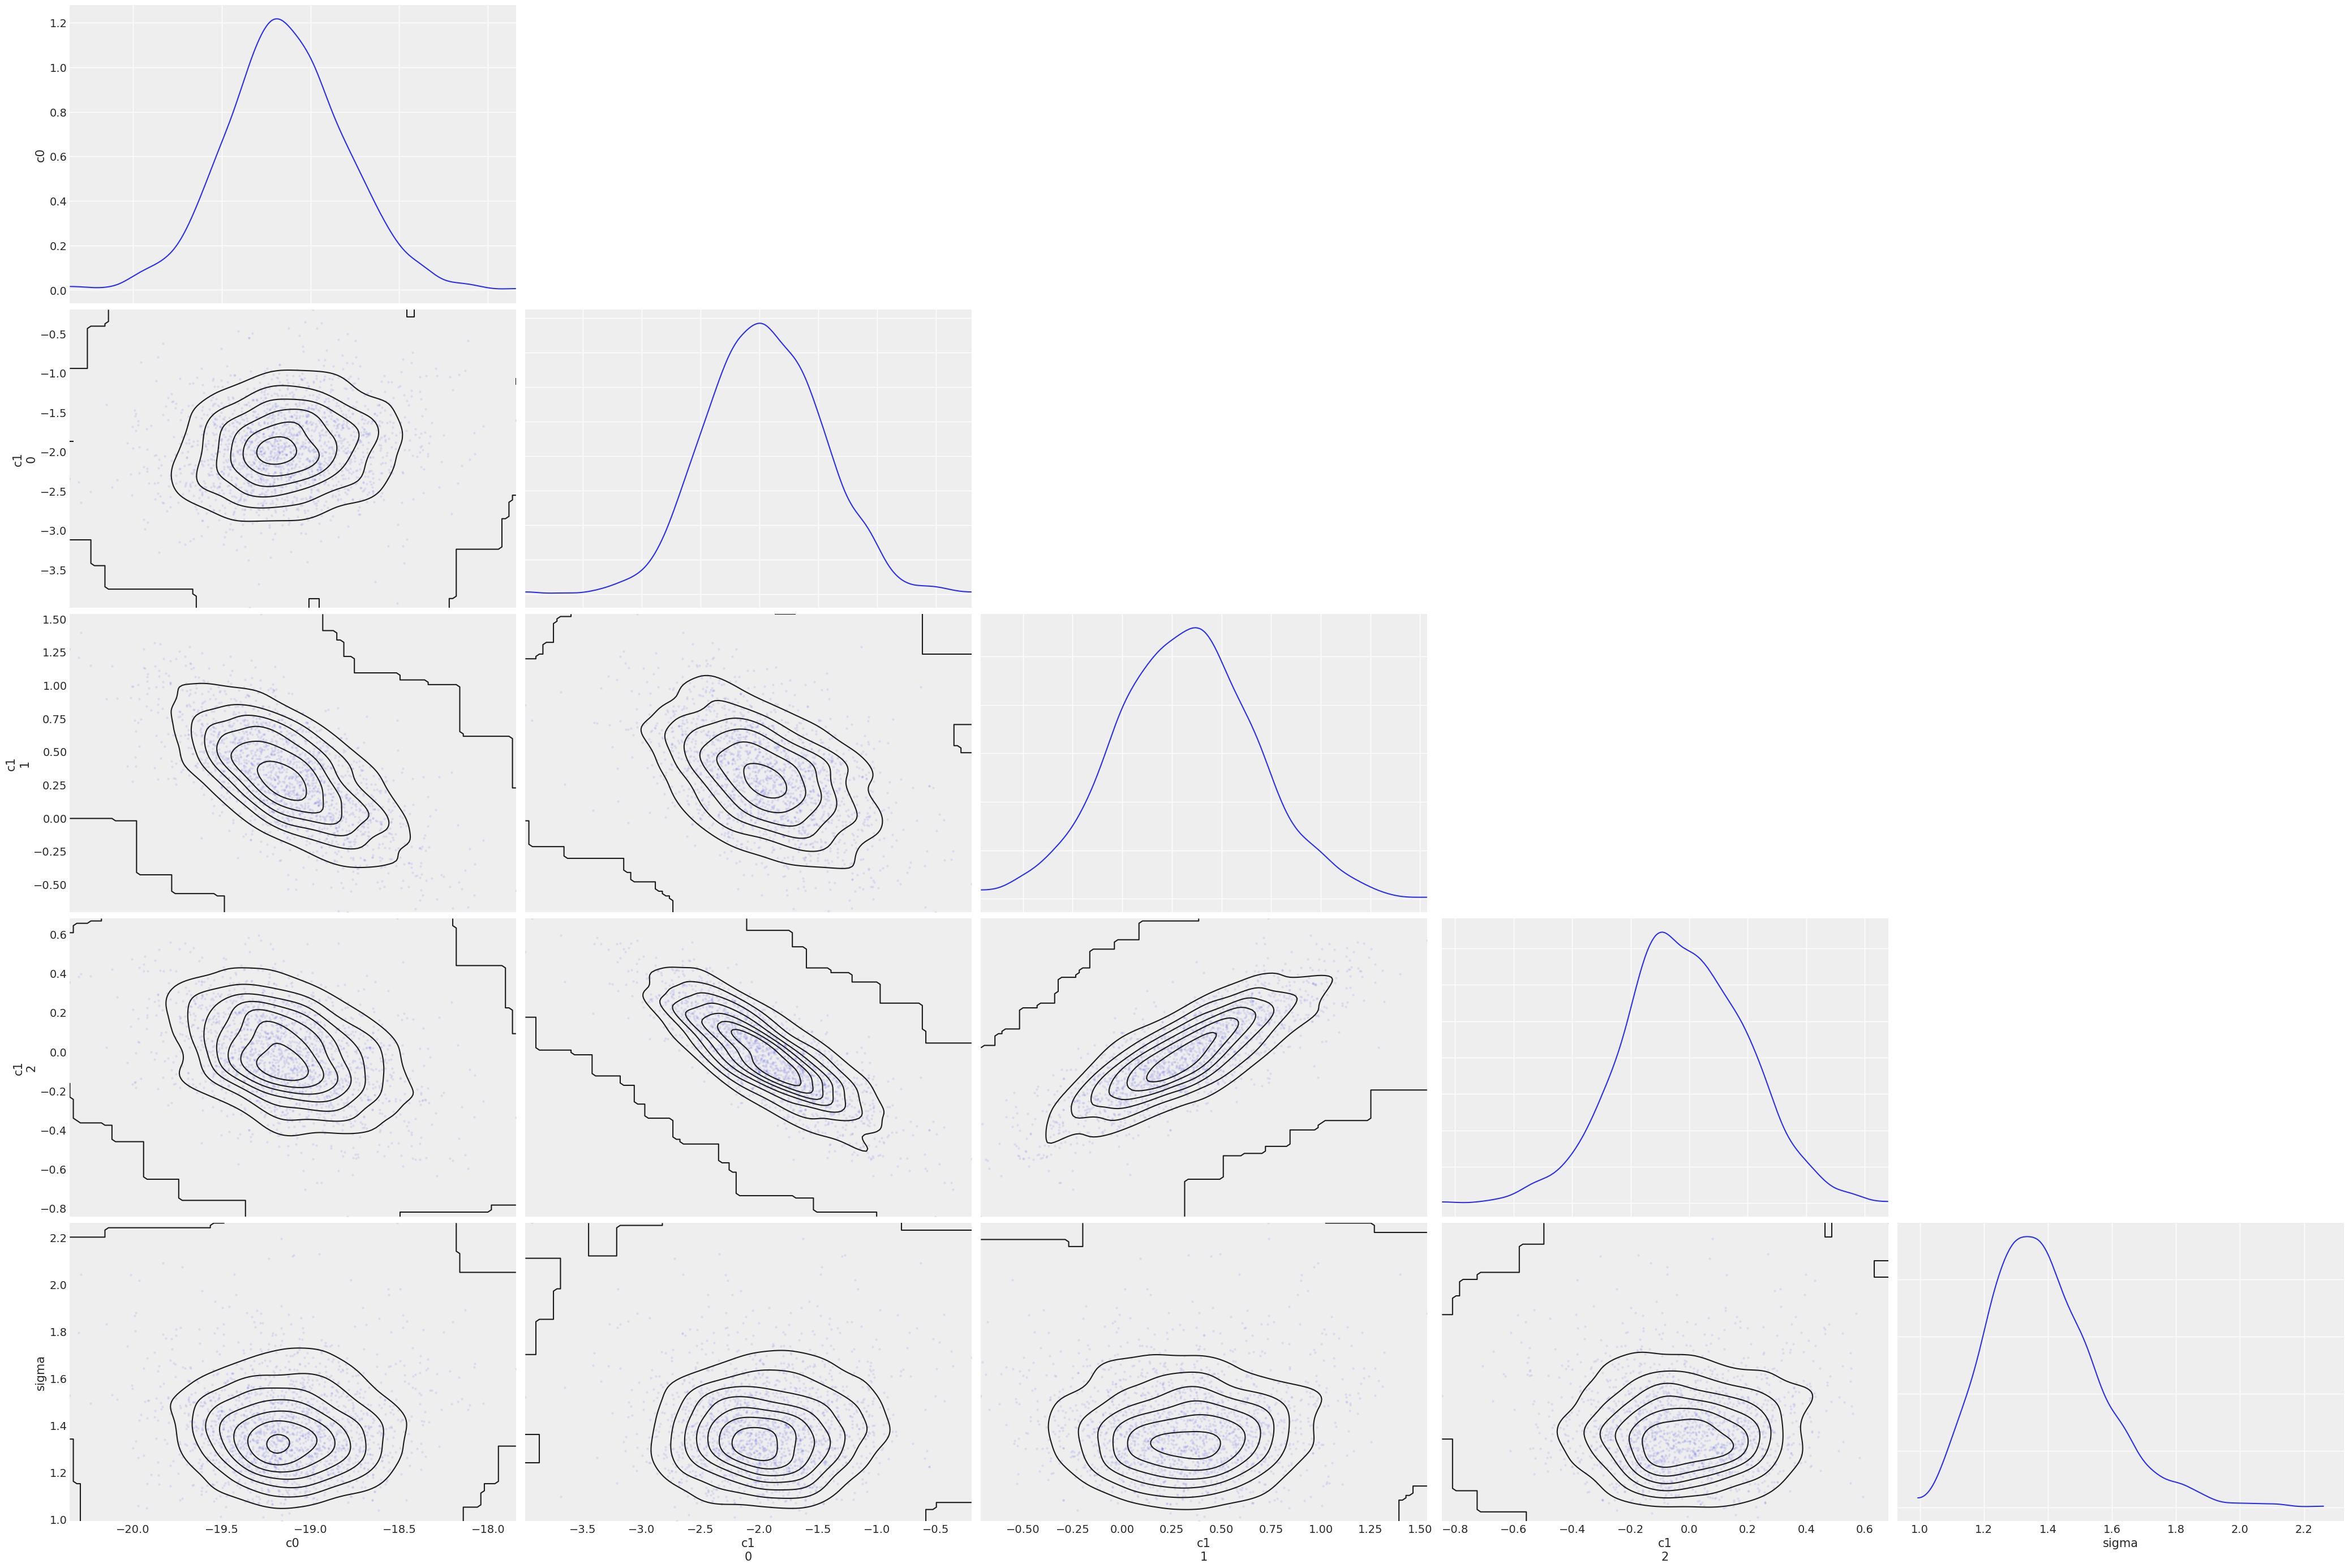

In [ ]:
az.plot_pair(inferences_normal[2],
             var_names=['c0', 'c1', 'sigma'],
             marginals=True,
             kind=["scatter", "kde"],
             scatter_kwargs={"color": "C0", "alpha": 0.1});

## Posterior and Posterior Predictive

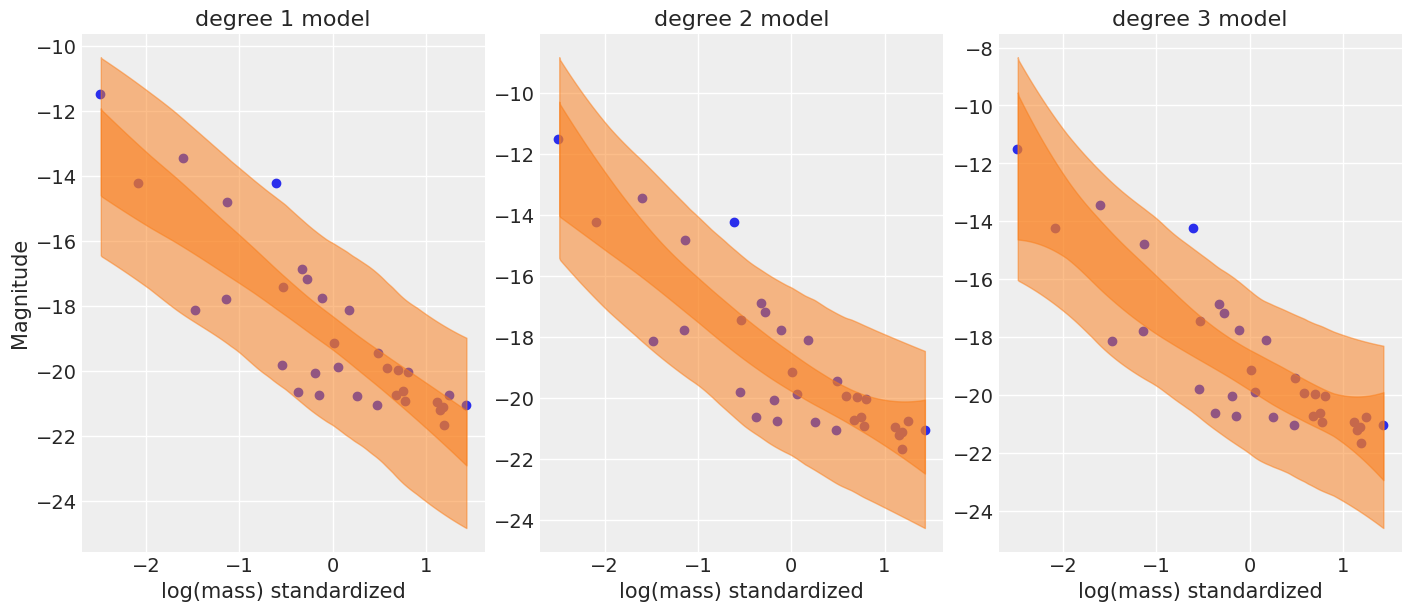

In [ ]:
# plotting the posterior distribution for degrees 1-3

plt.figure(figsize=(14, 6))

for i in range(3):
  plt.subplot(1, 3, i+1)
  plt.scatter(log_mass_std, data['mag'], label='data')
  az.plot_hdi(log_mass_std, inferences_normal[i].posterior['mu']
              , hdi_prob=0.95);
  az.plot_hdi(log_mass_std, predictive_normal[i].posterior_predictive['mag']
              , hdi_prob=0.95);

  plt.title(f'degree {i+1} model')
  plt.xlabel('log(mass) standardized')
  if i == 0:
    plt.ylabel('Magnitude')
plt.show()


## Comparing Different Degrees

The quadratic model seems to have the highest out-
of-sample predictive density. Yet, the credible interval of the linear model overlaps with the best
ELPD, meaning it can be as good as the quadratic one. On the other hand, the cubic model’s
credible interval has no overlap, implying that the quadratic model certainly outperforms it.

Given these three models, we can still say that the quadratic model is better for out-of-sample
prediction.

/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:792: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


           rank   elpd_loo     p_loo  elpd_diff    weight        se       dse  \
quadratic     0 -59.179175  3.598300   0.000000  0.738924  4.723402  0.000000   
linear        1 -59.768339  2.979893   0.589164  0.261076  4.079225  1.666707   
cubic         2 -60.778831  4.952348   1.599656  0.000000  4.785669  0.480290   

           warning scale  
quadratic    False   log  
linear       False   log  
cubic         True   log  


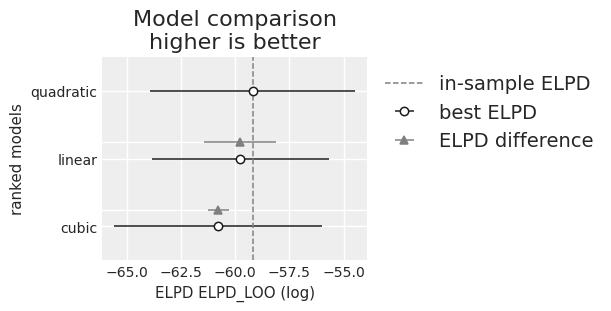

In [ ]:
# model comparison with PSIS
# the code is adapted from session 12 PCW

df = az.compare({'linear': inferences_normal[0], 'quadratic': inferences_normal[1],
                 'cubic': inferences_normal[2]}, ic='loo')
print(df)
az.plot_compare(df);
plt.title('Model comparison\nhigher is better')
plt.xlabel('ELPD ' + df.columns[1].upper() + ' (log)')
plt.legend(['in-sample ELPD', 'best ELPD', 'ELPD difference', 'ELPD'], loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.show()


# Student-T Likelihood

The Normal model may try to adjust its parameters to the outliers that are harder to predict given the Normal's light tails. We can tackle this issue by using a **Student-T** Likelihood function with a $\nu$ parameter that adjusts the heaviness of the tails. 

## Prior Selection
Since we have the same pre-assumptions about the data, we use the same prior distributions and parameters from the \textbf{Normal} model. Since we found the quadratic model to have the highest predictive accuracy, we continue with a $2^{nd}$ degree polynomial. We also add a prior distribution for the new parameter, $\nu$. Similar to what we have done in Session 8, we want the model to have enough flexibility to adjust to the presence or absence of outliers. Therefore, we use **HalfNormal** with a standard deviation of 30, which restricts the distribution to positive values but allowing for a wide range of values that go from $\nu = 1$ for highly heavy tails, and lighter tails as the value increases. 
To sum up, our **Student-T** model is defined as follows

\begin{align*}
    mag &\sim \text{StudentT}(\nu, \mu, \sigma) \quad (\text{likelihood})\\
    \nu  &\sim \text{HalfNormal}(\sigma=30) \\
    \sigma &\sim \text{LogNormal}(\mu=0, \sigma=1) \\
    \mu &= c_{0} +  c_{1_1}x + c_{1_2}x^{2} \\
    c_{0} &\sim \text{Normal}(\mu=0, \sigma=10) \\
    c_{1} &\sim \text{Normal}(\mu=0, \sigma=5)
\end{align*}


In [ ]:
# defining the StudentT model with a 2nd degree mu
with pm.Model() as t_model:
  mass = pm.Data('mass', log_mass_std)
  nu = pm.HalfNormal('nu', sigma=30)

  sigma = pm.LogNormal('sigma', mu=0, sigma=1)
  c0 = pm.Normal('c0', mu=0, sigma=10)
  c1 = pm.Normal('c1', mu=0, sigma=5, size=2)

  mu = pm.Deterministic('mu', c0 + c1[0] * mass + c1[1] * mass ** 2)
  mag = pm.StudentT('mag', nu=nu, mu=mu, sigma=sigma, observed=data['mag'])

  inference_t = pm.sample()
  pm.compute_log_likelihood(inference_t)


Output()

Output()

Output()

## Sampler Diagnostics

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c0,-19.190,0.339,-19.817,-18.553,0.010,0.007,1238.0,1145.0,1.0
c1[0],-1.990,0.293,-2.529,-1.423,0.007,0.005,1724.0,1543.0,1.0
c1[1],0.356,0.213,-0.052,0.758,0.006,0.004,1332.0,1172.0,1.0
sigma,1.274,0.199,0.917,1.661,0.006,0.004,962.0,694.0,1.0
nu,24.567,17.339,1.386,56.960,0.468,0.331,866.0,513.0,1.0


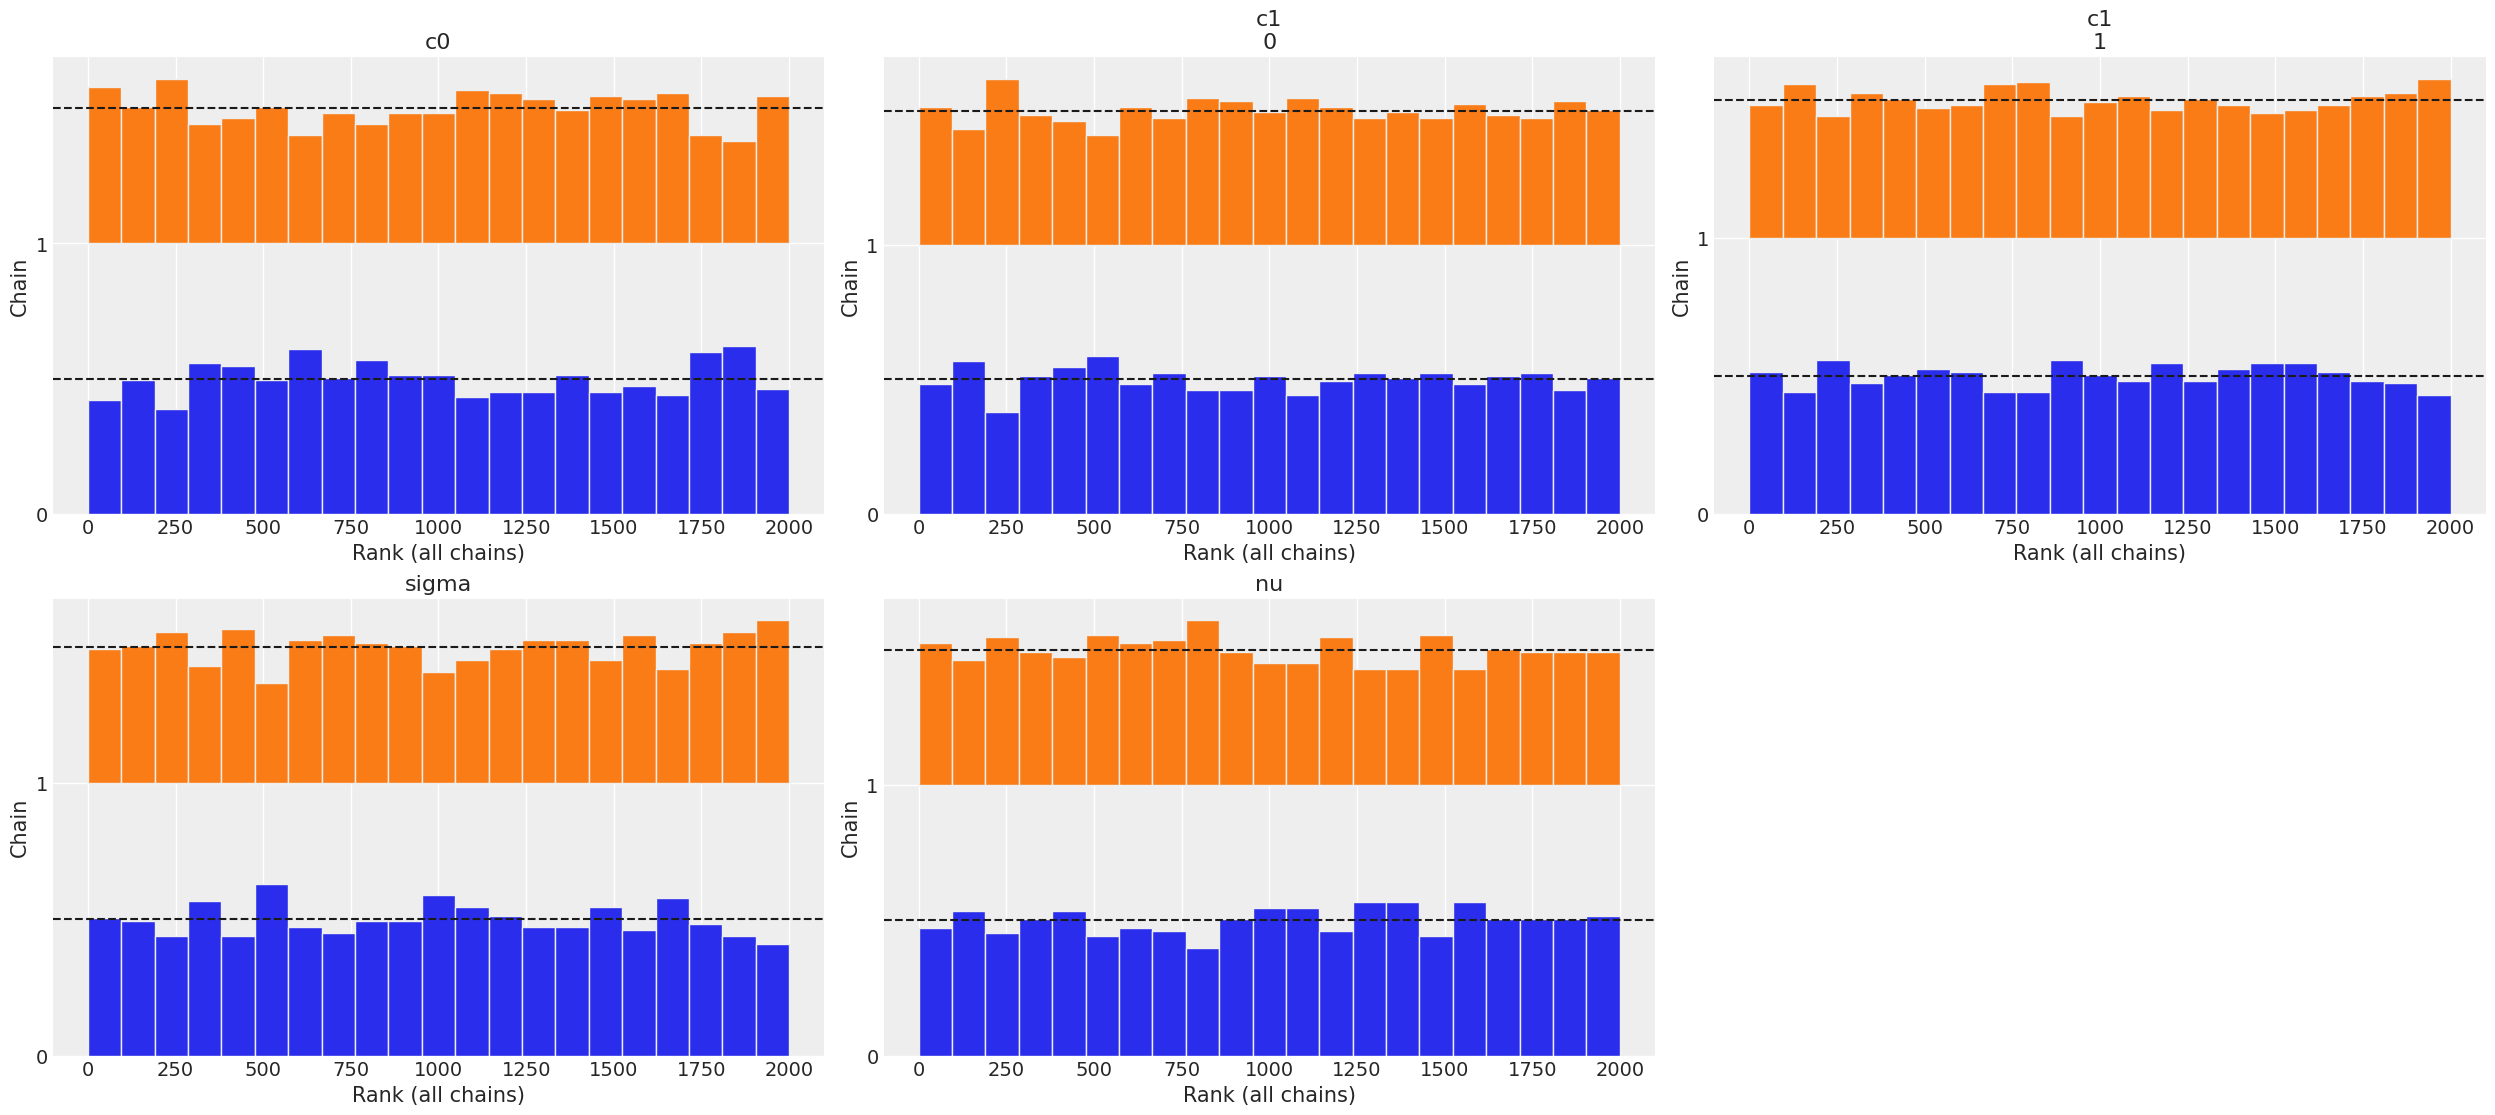

In [ ]:
az.plot_rank(inference_t, var_names=['c0', 'c1', 'sigma', 'nu']);
az.summary(inference_t, var_names=['c0', 'c1', 'sigma', 'nu'])

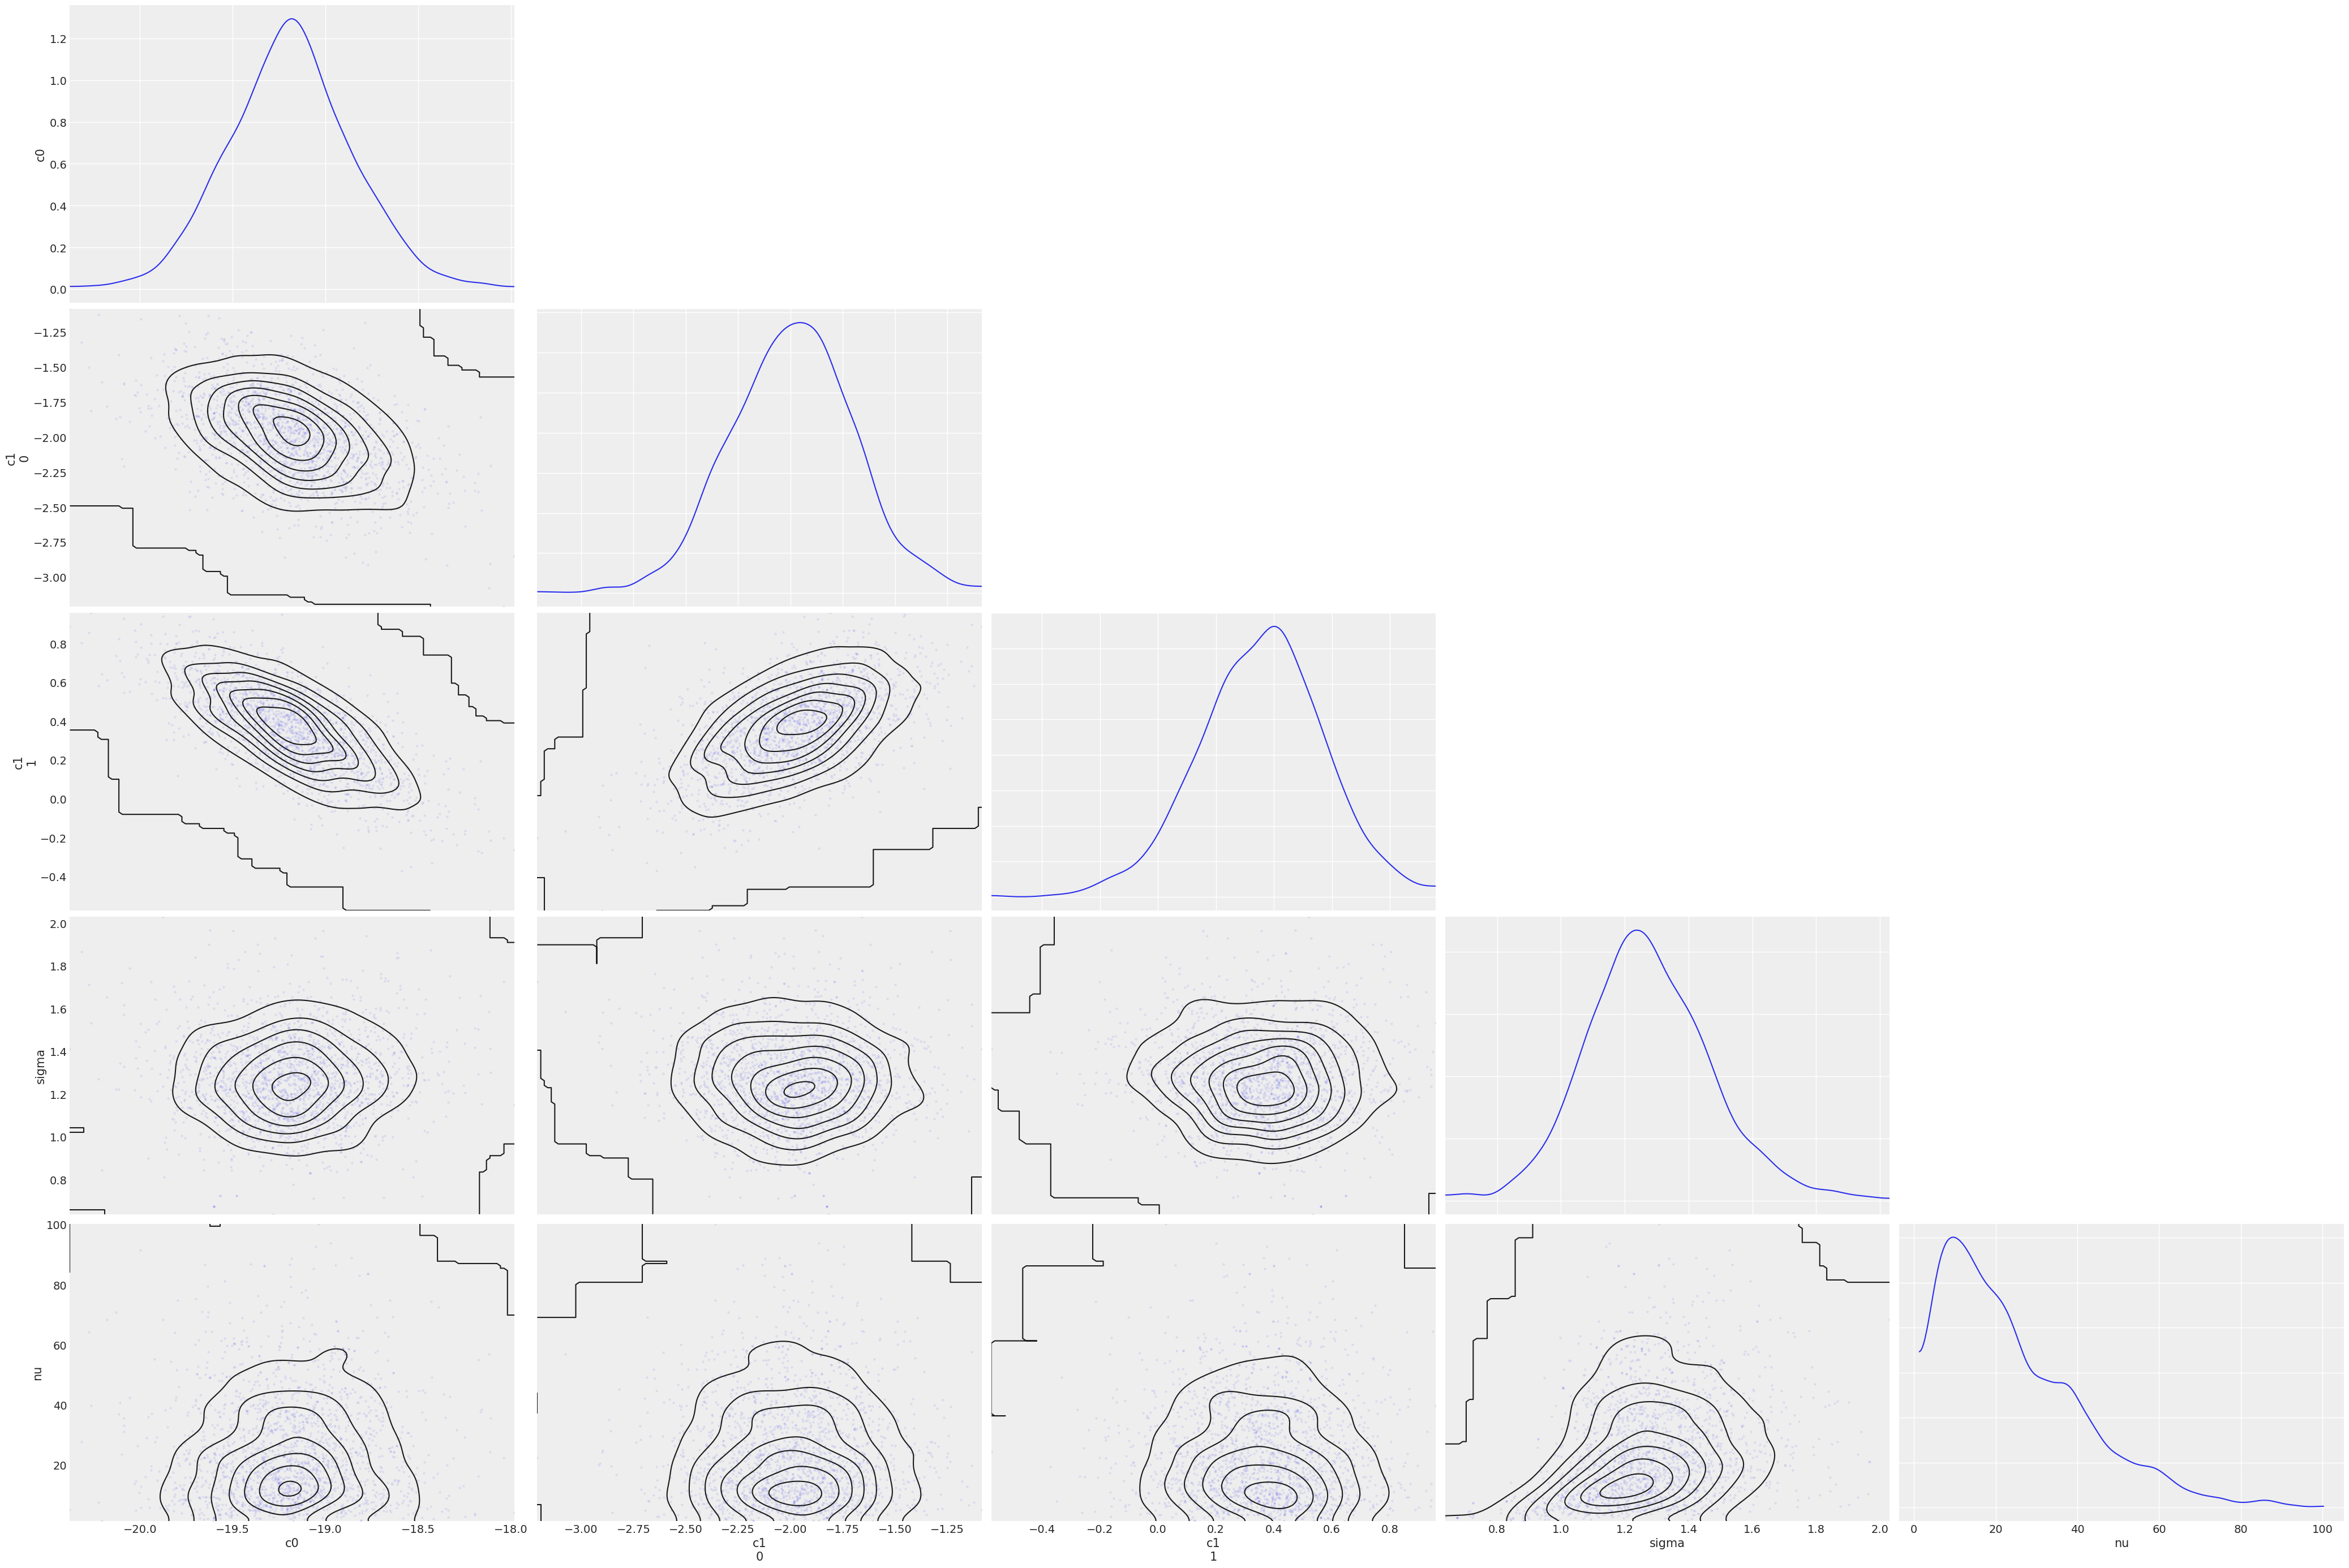

In [ ]:
az.plot_pair(inference_t,
             var_names=['c0', 'c1', 'sigma', 'nu'],
             marginals=True,
             kind=["scatter", "kde"],
             scatter_kwargs={"color": "C0", "alpha": 0.1});

## Posterior and Posterior Predictive

In [ ]:
# generating samples from the posterior predictive
with t_model:
  predictive_t = pm.sample_posterior_predictive(inference_t)

Output()

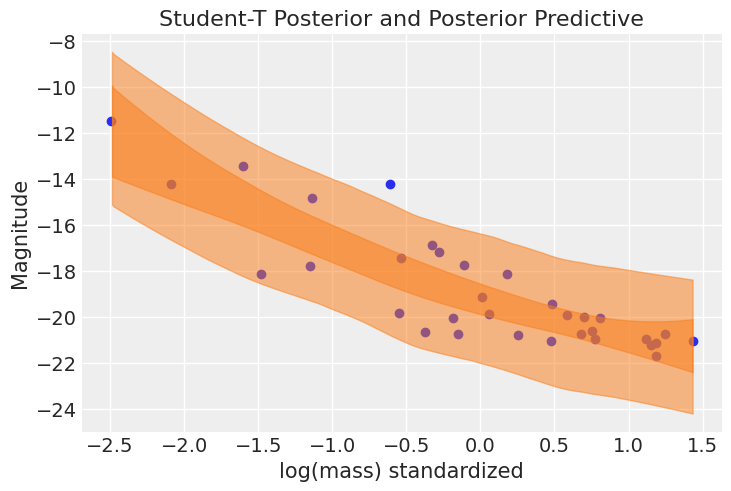

In [ ]:
# plotting the Student-T posterior and posterior predictive

plt.scatter(log_mass_std, data['mag'])
az.plot_hdi(log_mass_std, inference_t.posterior['mu'], hdi_prob=0.95);
az.plot_hdi(log_mass_std, predictive_t.posterior_predictive['mag'], hdi_prob=0.95);
plt.xlabel('log(mass) standardized')
plt.ylabel('Magnitude')
plt.title('Student-T Posterior and Posterior Predictive')
plt.show()


# Normal vs Student-T

The main difference between the two models
is the distribution over σ. As expected, the Student-T has a lower mean for σ since the heaviness
of the tails allows the model to account for further data points without increasing the standard
deviation.

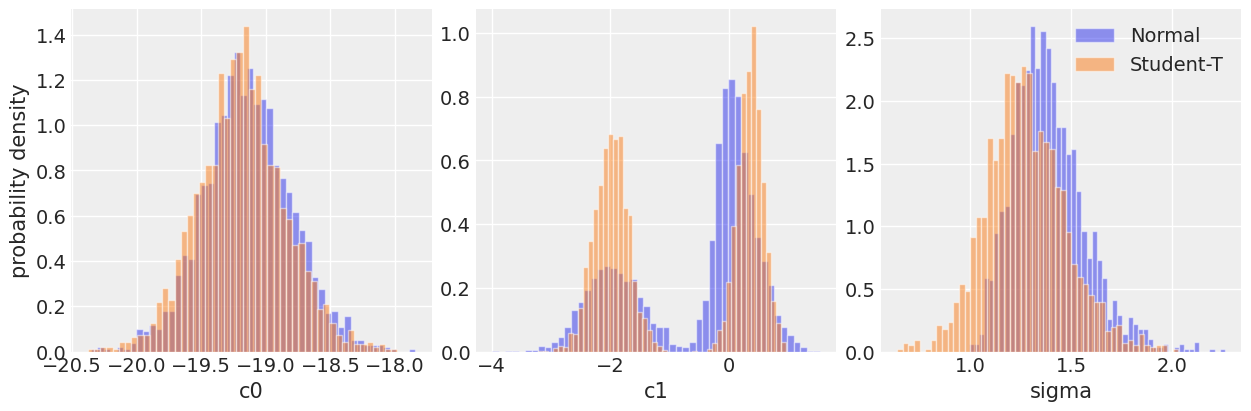

In [ ]:
# comparing the posterior between the Normal and Student-T
# the code is adapted from session 8 discussion
plt.figure(figsize=(16, 4))
for i, var in enumerate(['c0', 'c1', 'sigma']):
    plt.subplot(1, 4, i+1)
    plt.xlabel(var)
    if i == 0:
        plt.ylabel('probability density')
    plt.hist(getattr(inferences_normal[2].posterior, var).values.flatten(),
             density=True, bins=50, edgecolor='white', alpha=0.5, label='Normal')
    plt.hist(getattr(inference_t.posterior, var).values.flatten(), density=True,
             bins=50, edgecolor='white', alpha=0.5, label='Student-T')
plt.legend()
plt.show()

The model with Student-T likelihood has the highest out-of-sample
predictive accuracy. We still see an overlap between the Normal’s credible interval and the in-
sample ELPD, which indicates that the Normal model can still be as good as the Student-T or
better given the wide intervals for both models.

/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:792: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


           rank   elpd_loo     p_loo  elpd_diff  weight        se       dse  \
student-t     0 -59.531341  4.149363   0.000000     1.0  4.646507  0.000000   
normal        1 -60.358388  4.582747   0.827047     0.0  4.739155  0.532722   

           warning scale  
student-t    False   log  
normal        True   log  


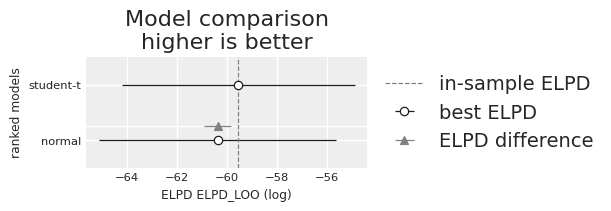

In [ ]:
# comparing the Normal and Student-T with PSIS
df_normal_t = az.compare({'normal': inferences_normal[2], 'student-t':inference_t},
                         ic='loo')
print(df_normal_t)

az.plot_compare(df_normal_t);
plt.title('Model comparison\nhigher is better')
plt.xlabel('ELPD ' + df_normal_t.columns[1].upper() + ' (log)')
plt.legend(['in-sample ELPD', 'best ELPD', 'ELPD difference', 'ELPD'],
           loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.show()
